# non-SNP Bonferroni hits — overlap across models and across climate axes

Source: `multiaxis/significant_blocks_bonferroni.csv` (built from the current isotonic
+ 3-class WZA output), filtered to the **non-SNP** class (pooled SV+indel). Two
questions: (1) do kendall / lfmm / binomial agree on which blocks are significant,
pooled over all 20 axes? (2) do the 20 climate axes (bio1-19 + PC1) point at the same
blocks, or are hits mostly axis-specific? No chart titles per repo convention.

In [1]:

import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
os.chdir("/global/scratch/projects/fc_moilab/tbellg/kmate")
sys.path.insert(0, "analysis/grenenet_gea")
import lib
DIR = "analysis/grenenet_gea/phase1_replication/results/multiaxis"
MODELS = ["kendall", "lfmm", "binomial"]
AXES = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
MCOL = {"kendall": "#3A5A98", "lfmm": "#E07A5F", "binomial": "#588157"}

B = pd.read_csv(f"{DIR}/significant_blocks_bonferroni.csv")
B = B[B.cls == "nonsnp"].copy()
print(f"nonsnp Bonferroni rows: {len(B)} | unique blocks: {B.block.nunique()} | "
      f"models: {sorted(B.model.unique())} | axes: {B.axis.nunique()}/{len(AXES)}")
GENES = lib.load_genes()
def gene_label(row):
    gs = str(row.genes).split(";") if pd.notna(row.genes) and row.genes else []
    return gs[0] if gs else row.block


nonsnp Bonferroni rows: 161 | unique blocks: 85 | models: ['binomial', 'kendall', 'lfmm'] | axes: 20/20


## 1. Cross-model overlap (pooled over all 20 axes)

Each model's hit-set = every (axis, block) pair it calls Bonferroni-significant for
the non-SNP class, anywhere across the 20 climate axes. The Venn shows how much of
that is model-specific vs shared.

kendall  :   61 (axis,block) hits
lfmm     :   51 (axis,block) hits
binomial :   49 (axis,block) hits


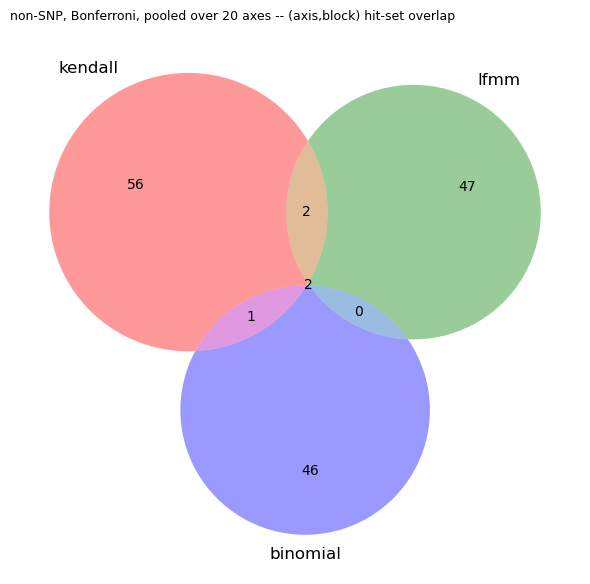


pairwise Jaccard:
  kendall   vs lfmm     : shared    4 / union  108  Jaccard=0.037
  kendall   vs binomial : shared    3 / union  107  Jaccard=0.028
  lfmm      vs binomial : shared    2 / union   98  Jaccard=0.020

all 3 models agree: 2 (axis,block) hits -> blocks: ['Chr1_6372', 'Chr5_4219']


In [2]:

from matplotlib_venn import venn3

hits = {m: set(zip(B.loc[B.model == m, "axis"], B.loc[B.model == m, "block"])) for m in MODELS}
for m in MODELS:
    print(f"{m:9s}: {len(hits[m]):4d} (axis,block) hits")

fig, ax = plt.subplots(figsize=(6, 6))
venn3([hits["kendall"], hits["lfmm"], hits["binomial"]], set_labels=MODELS, ax=ax)
ax.annotate("non-SNP, Bonferroni, pooled over 20 axes -- (axis,block) hit-set overlap",
            (0.0, 1.02), xycoords="axes fraction", fontsize=9, va="bottom")
fig.tight_layout(); plt.show()

print("\npairwise Jaccard:")
for a, b in [("kendall", "lfmm"), ("kendall", "binomial"), ("lfmm", "binomial")]:
    sa, sb = hits[a], hits[b]
    j = len(sa & sb) / len(sa | sb) if (sa | sb) else float("nan")
    print(f"  {a:9s} vs {b:9s}: shared {len(sa & sb):4d} / union {len(sa | sb):4d}  Jaccard={j:.3f}")
allthree = hits["kendall"] & hits["lfmm"] & hits["binomial"]
print(f"\nall 3 models agree: {len(allthree)} (axis,block) hits -> blocks: {sorted({b for _, b in allthree})}")


## 2. Cross-axis overlap — do the 20 climate axes point at the same blocks?

For each axis, the non-SNP Bonferroni-significant block set (any of the 3 models).
Pairwise Jaccard similarity between axes, as a heatmap — dark = two climate variables
implicate largely the same blocks (expected for correlated bioclim axes, e.g.
temperature-family variables), pale = independent hit sets.

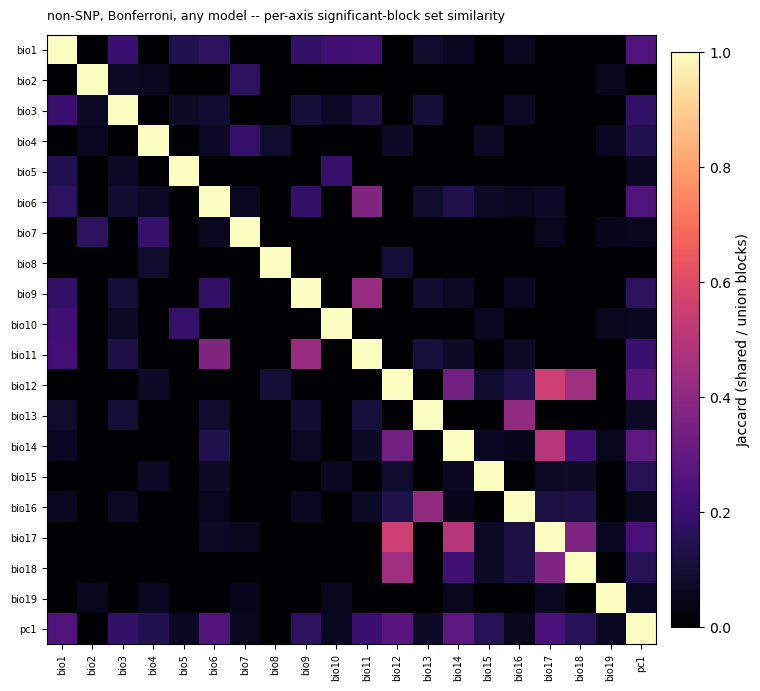

off-diagonal Jaccard: mean=0.061  median=0.000  max=0.556
most-similar axis pair: bio12 vs bio17  (Jaccard=0.556)


In [3]:

axis_sets = {ax: set(B.loc[B.axis == ax, "block"]) for ax in AXES if ax in B.axis.unique()}
present = [ax for ax in AXES if ax in axis_sets]
n = len(present)
J = np.zeros((n, n))
for i, a in enumerate(present):
    for j, b in enumerate(present):
        sa, sb = axis_sets[a], axis_sets[b]
        J[i, j] = len(sa & sb) / len(sa | sb) if (sa | sb) else 0.0

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(J, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(present, rotation=90, fontsize=7)
ax.set_yticks(range(n)); ax.set_yticklabels(present, fontsize=7)
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02); cb.set_label("Jaccard (shared / union blocks)")
ax.annotate("non-SNP, Bonferroni, any model -- per-axis significant-block set similarity",
            (0.0, 1.02), xycoords="axes fraction", fontsize=9, va="bottom")
fig.tight_layout(); plt.show()

offdiag = J[np.triu_indices(n, k=1)]
print(f"off-diagonal Jaccard: mean={offdiag.mean():.3f}  median={np.median(offdiag):.3f}  max={offdiag.max():.3f}")
i, j = np.unravel_index(np.argmax(J - np.eye(n)), J.shape)
print(f"most-similar axis pair: {present[i]} vs {present[j]}  (Jaccard={J[i,j]:.3f})")


## 3. Recurrence dot-grid — blocks that recur across >=2 axes

Rows = non-SNP Bonferroni blocks significant in **>=2 of the 20 axes** (gene-labelled
where known), columns = the 20 axes. Dot present if significant in >=1 model at that
(block, axis); colour = how many of the 3 models agree there (pale=1, dark=3).

34 blocks significant (non-SNP, Bonferroni, any model) in >=2 axes


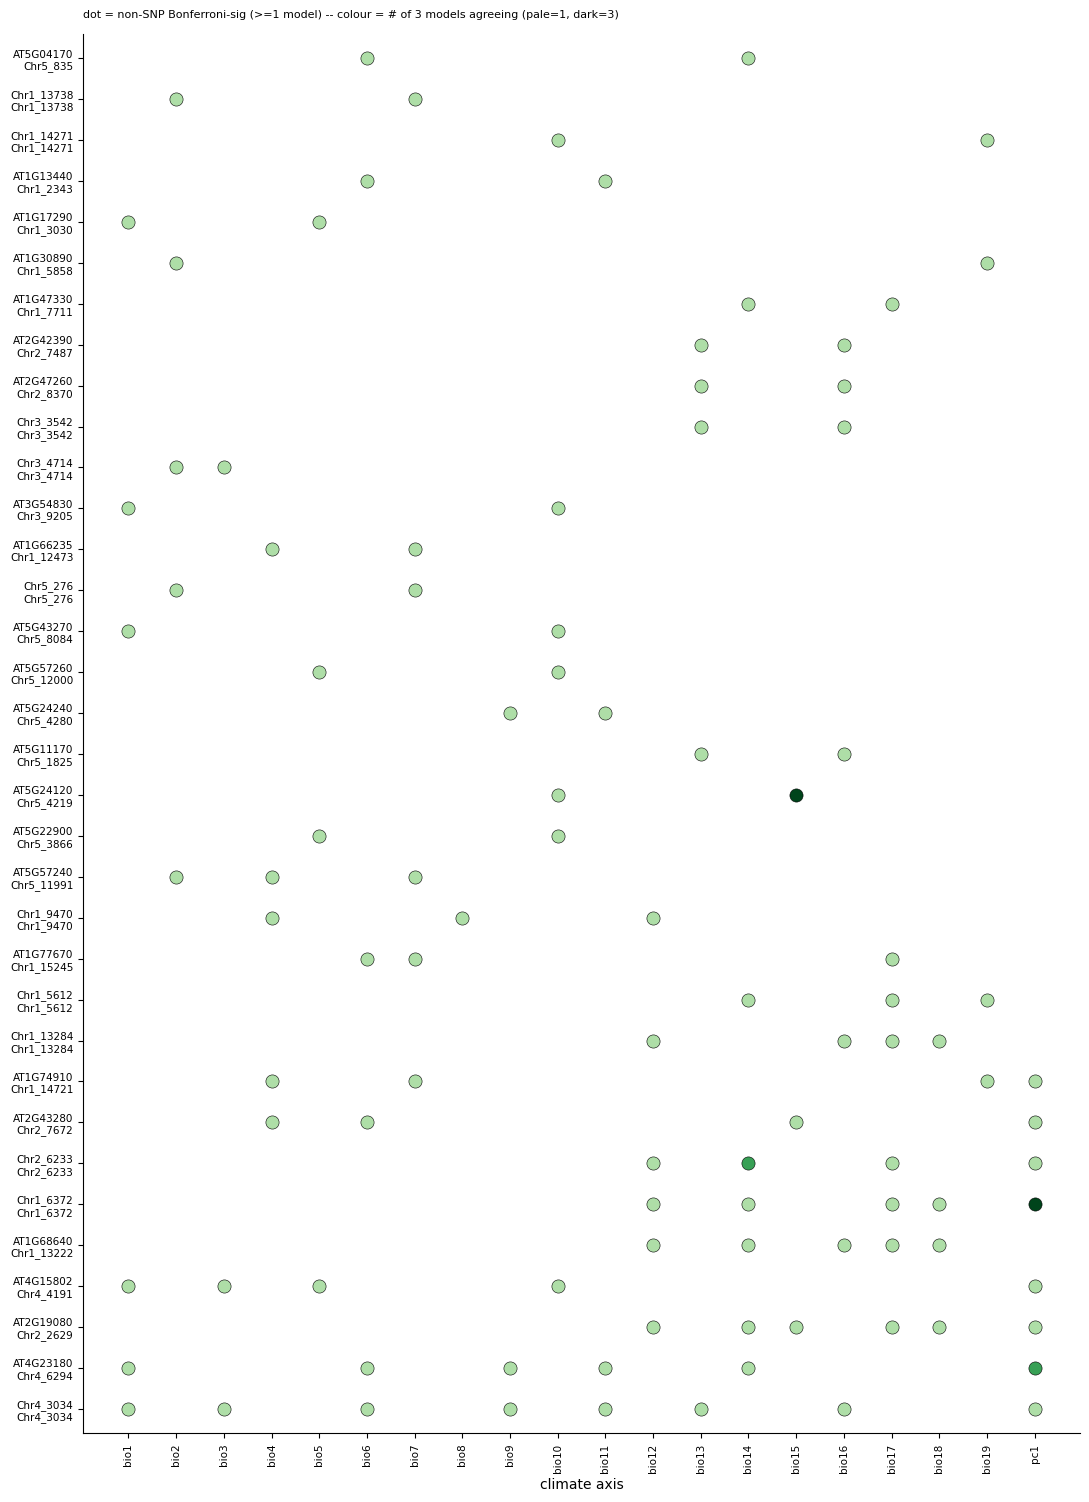

In [4]:

agree = B.groupby(["block", "axis"])["model"].nunique().rename("n_models").reset_index()
recur_blocks = agree.groupby("block")["axis"].nunique()
recur_blocks = recur_blocks[recur_blocks >= 2].sort_values(ascending=False)
print(f"{len(recur_blocks)} blocks significant (non-SNP, Bonferroni, any model) in >=2 axes")

if len(recur_blocks):
    labels = {}
    for blk in recur_blocks.index:
        row = B[B.block == blk].iloc[0]
        labels[blk] = gene_label(row)

    fig, ax = plt.subplots(figsize=(11, 0.4 * len(recur_blocks) + 1.5))
    cmap = plt.cm.Greens
    for yi, blk in enumerate(recur_blocks.index):
        sub = agree[agree.block == blk]
        for _, r in sub.iterrows():
            xi = AXES.index(r.axis)
            ax.scatter(xi, yi, s=90, c=[cmap(r.n_models / 3)], edgecolors="k", linewidths=0.4, zorder=2)
    ax.set_yticks(range(len(recur_blocks)))
    ax.set_yticklabels([f"{labels[b]}\n{b}" for b in recur_blocks.index], fontsize=7.5)
    ax.set_xticks(range(len(AXES))); ax.set_xticklabels(AXES, rotation=90, fontsize=7.5)
    ax.set_xlabel("climate axis"); ax.set_ylim(-0.6, len(recur_blocks) - 0.4)
    ax.annotate("dot = non-SNP Bonferroni-sig (>=1 model) -- colour = # of 3 models agreeing (pale=1, dark=3)",
                (0.0, 1.01), xycoords="axes fraction", fontsize=8, va="bottom")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    fig.tight_layout(); plt.show()
